# SEP Occurrence Forecasting — Keras 3 — PyTorch Backend

This research-style workflow uses the archived train/test pickles exactly
as supplied. The 49 predictors are anonymous, and the archive has no event IDs
or timestamps. Consequently, this is sample-level teaching evidence: it cannot
establish event-aware generalization or physical feature attribution.

Set `HELIO_FAST_RUN=1` for a one-epoch smoke run. In Colab, choose
**Runtime → Run all**; the bootstrap downloads and verifies only four pickles.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports and deterministic configuration

In [3]:
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
FAST_RUN = os.getenv("HELIO_FAST_RUN", "0") == "1"
random.seed(SEED)
np.random.seed(SEED)

## Resolve the immutable archive

In [4]:
import hashlib
import os
from pathlib import Path
from urllib.parse import quote
from urllib.request import urlopen

DATASET_ID = 'sep-curated'
DATASET_FILES = {'x_train.pkl': ('data/sep-curated/x_train.pkl', 'e809bf00498633f509a223d61f9b0006e6ed1803f6de22118bcf654f2ce8ba3b'), 'x_test.pkl': ('data/sep-curated/x_test.pkl', '1d0c5f84713d4fde34d567cdb62e9081c4d723f6fef9abd543137376350d5955'), 'y_train.pkl': ('data/sep-curated/y_train.pkl', 'd7aa048f6b081a9fb1fc00dde19872c0f67ae5b4c8620daa5984b679f9f9dbdc'), 'y_test.pkl': ('data/sep-curated/y_test.pkl', 'd44c5af108bab2b19f5f8082548282edd8aee89d57e15469516de1ca3f400ee5')}


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_dataset():
    resolved = {}
    override = os.getenv("HELIO_DATA_DIR")
    cache_root = Path(
        os.getenv("HELIO_DATA_CACHE", Path.home() / ".cache" / "helio-data-methods")
    ) / "datasets" / DATASET_ID
    for filename, (relative_path, checksum) in DATASET_FILES.items():
        candidates = []
        if override:
            root = Path(override).expanduser()
            candidates.extend([root / DATASET_ID / filename, root / filename])
        for root in [Path.cwd(), *Path.cwd().parents]:
            candidates.append(root / relative_path)
        target = cache_root / filename
        candidates.append(target)
        match = next(
            (
                candidate
                for candidate in candidates
                if candidate.is_file() and file_sha256(candidate) == checksum
            ),
            None,
        )
        if match is None:
            target.parent.mkdir(parents=True, exist_ok=True)
            ref = os.getenv("HELIO_DATA_REF", "main")
            url = (
                "https://raw.githubusercontent.com/SavvasRaptis/helio-data-methods/"
                f"{quote(ref, safe='')}/{quote(relative_path, safe='/')}"
            )
            try:
                with urlopen(url, timeout=120) as response, target.open("wb") as output:
                    while chunk := response.read(1024 * 1024):
                        output.write(chunk)
            except Exception as exc:
                target.unlink(missing_ok=True)
                raise RuntimeError(
                    f"Could not retrieve {DATASET_ID}/{filename}. Check network "
                    "access or set HELIO_DATA_DIR to the archived data directory."
                ) from exc
            if file_sha256(target) != checksum:
                target.unlink(missing_ok=True)
                raise ValueError(
                    f"Checksum mismatch for {DATASET_ID}/{filename}; "
                    "the invalid download was removed."
                )
            match = target
        resolved[filename] = match
    return resolved


dataset_files = resolve_dataset()
print("verified dataset:", DATASET_ID)
for name in dataset_files:
    print(f"  {name} (checksum verified)")

verified dataset: sep-curated
  x_train.pkl: data/sep-curated/x_train.pkl
  x_test.pkl: data/sep-curated/x_test.pkl
  y_train.pkl: data/sep-curated/y_train.pkl
  y_test.pkl: data/sep-curated/y_test.pkl


## Preserve the supplied test set and split training samples

In [5]:
x_supplied_train = pd.read_pickle(dataset_files["x_train.pkl"]).to_numpy(dtype=np.float32)
x_test = pd.read_pickle(dataset_files["x_test.pkl"]).to_numpy(dtype=np.float32)
y_supplied_train = (
    pd.read_pickle(dataset_files["y_train.pkl"]).to_numpy().reshape(-1).astype(np.int64)
)
y_test = pd.read_pickle(dataset_files["y_test.pkl"]).to_numpy().reshape(-1).astype(np.int64)
feature_names = np.asarray([f"anonymous feature {i}" for i in range(x_test.shape[1])])

train_indices, validation_indices = train_test_split(
    np.arange(len(y_supplied_train)),
    test_size=0.15,
    random_state=SEED,
    stratify=y_supplied_train,
)
if FAST_RUN:
    train_indices, _ = train_test_split(
        train_indices,
        train_size=min(4000, len(train_indices)),
        random_state=SEED,
        stratify=y_supplied_train[train_indices],
    )
    validation_indices, _ = train_test_split(
        validation_indices,
        train_size=min(1200, len(validation_indices)),
        random_state=SEED,
        stratify=y_supplied_train[validation_indices],
    )

x_train_raw = x_supplied_train[train_indices]
y_train = y_supplied_train[train_indices]
x_validation_raw = x_supplied_train[validation_indices]
y_validation = y_supplied_train[validation_indices]
scaler = StandardScaler().fit(x_train_raw)
x_train = scaler.transform(x_train_raw).astype(np.float32)
x_validation = scaler.transform(x_validation_raw).astype(np.float32)
x_test_scaled = scaler.transform(x_test).astype(np.float32)

counts = np.bincount(y_train, minlength=2)
majority_class = int(np.argmax(counts))
majority_prediction = np.full_like(y_test, majority_class)
class_weights = len(y_train) / (2.0 * np.maximum(counts, 1))
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"supplied test={len(y_test):,}, positive prevalence={y_train.mean():.4f}"
)
print("class weights:", dict(enumerate(class_weights.round(3))))

train=13,846, validation=2,444, supplied test=1,811, positive prevalence=0.0125
class weights: {0: 0.506, 1: 40.017}


## Establish the majority-class baseline

In [6]:
def classification_evidence(y_true, probability, label):
    prediction = (probability >= 0.5).astype(np.int64)
    evidence = {
        "accuracy": float(accuracy_score(y_true, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, prediction)),
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "confusion_matrix": confusion_matrix(y_true, prediction, labels=[0, 1]).tolist(),
    }
    print(label, json.dumps(evidence, indent=2))
    print(classification_report(y_true, prediction, digits=3, zero_division=0))
    return evidence


majority_probability = np.full(len(y_test), float(majority_class))
majority_evidence = classification_evidence(
    y_test, majority_probability, "majority-class baseline"
)

majority-class baseline {
  "accuracy": 0.9872998343456654,
  "balanced_accuracy": 0.5,
  "roc_auc": 0.5,
  "pr_auc": 0.012700165654334622,
  "confusion_matrix": [
    [
      1788,
      0
    ],
    [
      23,
      0
    ]
  ]
}
              precision    recall  f1-score   support

           0      0.987     1.000     0.994      1788
           1      0.000     0.000     0.000        23

    accuracy                          0.987      1811
   macro avg      0.494     0.500     0.497      1811
weighted avg      0.975     0.987     0.981      1811



## Train the weighted Keras classifier

In [7]:
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch
from keras import layers

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)
assert keras.backend.backend() == "torch"
model = keras.Sequential(
    [
        keras.Input(shape=(x_train.shape[1],)),
        layers.Dense(40, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dense(30, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=1 if FAST_RUN else 40,
    batch_size=256,
    class_weight={0: class_weights[0], 1: class_weights[1]},
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ],
    verbose=2,
)
probabilities = model.predict(x_test_scaled, verbose=0).reshape(-1)

Epoch 1/40


55/55 - 1s - 12ms/step - accuracy: 0.8585 - loss: 0.3950 - val_accuracy: 0.9877 - val_loss: 0.1709


Epoch 2/40


55/55 - 0s - 7ms/step - accuracy: 0.9882 - loss: 0.1100 - val_accuracy: 0.9885 - val_loss: 0.0826


Epoch 3/40


...

55/55 - 1s - 11ms/step - accuracy: 0.9909 - loss: 0.0315 - val_accuracy: 0.9881 - val_loss: 0.0373


Epoch 23/40


55/55 - 0s - 9ms/step - accuracy: 0.9914 - loss: 0.0304 - val_accuracy: 0.9881 - val_loss: 0.0368


Epoch 24/40


55/55 - 0s - 9ms/step - accuracy: 0.9911 - loss: 0.0316 - val_accuracy: 0.9885 - val_loss: 0.0376


## Inspect learning behavior

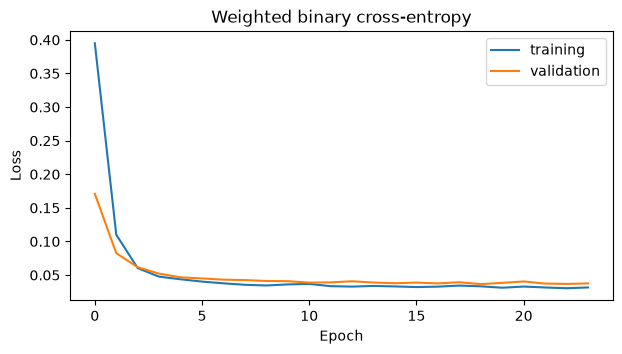

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")
ax.set(title="Weighted binary cross-entropy", xlabel="Epoch", ylabel="Loss")
ax.legend()
plt.show()

## Evaluate the untouched supplied test set

model {
  "accuracy": 0.9895085588072888,
  "balanced_accuracy": 0.7371729403754499,
  "roc_auc": 0.9804007392277015,
  "pr_auc": 0.5942633590029494,
  "confusion_matrix": [
    [
      1781,
      7
    ],
    [
      12,
      11
    ]
  ]
}
              precision    recall  f1-score   support

           0      0.993     0.996     0.995      1788
           1      0.611     0.478     0.537        23

    accuracy                          0.990      1811
   macro avg      0.802     0.737     0.766      1811
weighted avg      0.988     0.990     0.989      1811



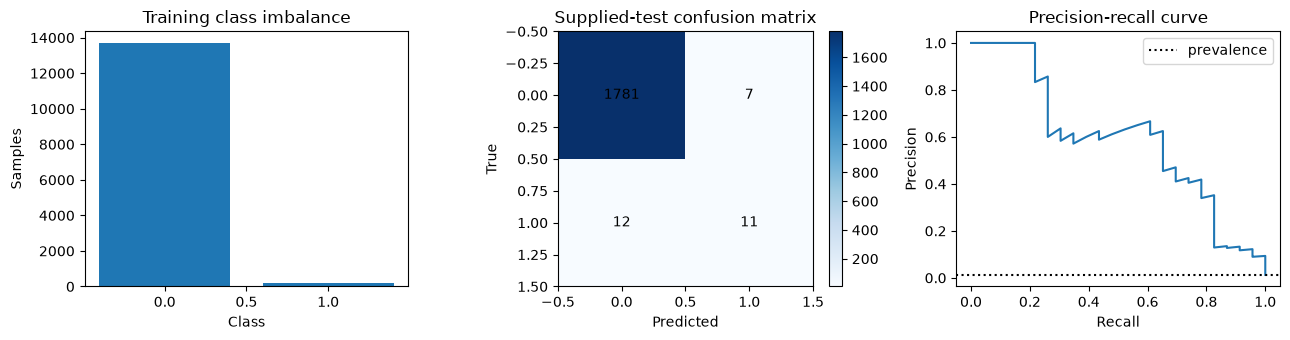

HELIO_RESULT {"balanced_accuracy": 0.7371729403754499, "majority_balanced_accuracy": 0.5, "pr_auc": 0.5942633590029494, "prediction_shape": [1811], "roc_auc": 0.9804007392277015}


In [9]:
model_evidence = classification_evidence(y_test, probabilities, "model")
matrix = np.asarray(model_evidence["confusion_matrix"])
precision, recall, _ = precision_recall_curve(y_test, probabilities)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].bar([0, 1], np.bincount(y_train, minlength=2))
axes[0].set(title="Training class imbalance", xlabel="Class", ylabel="Samples")
image = axes[1].imshow(matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(matrix):
    axes[1].text(column, row, str(value), ha="center", va="center")
axes[1].set(title="Supplied-test confusion matrix", xlabel="Predicted", ylabel="True")
fig.colorbar(image, ax=axes[1], fraction=0.046)
axes[2].plot(recall, precision)
axes[2].axhline(y_test.mean(), linestyle=":", color="black", label="prevalence")
axes[2].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[2].legend()
plt.tight_layout()
plt.show()

print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "balanced_accuracy": model_evidence["balanced_accuracy"],
            "majority_balanced_accuracy": majority_evidence["balanced_accuracy"],
            "roc_auc": model_evidence["roc_auc"],
            "pr_auc": model_evidence["pr_auc"],
            "prediction_shape": list(probabilities.shape),
        },
        sort_keys=True,
    )
)
assert probabilities.shape == y_test.shape
assert np.isfinite(probabilities).all()